In [39]:
# ==============================================================================
# REFINED DUAL MODEL COMPARATIVE SIMULATION & VISUALIZATION DASHBOARD
# ==============================================================================

import io
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

In [40]:

# ------------------------------------------------------------------------------
# 1. SETUP & CONSTANTS
# ------------------------------------------------------------------------------
N_SIMULATIONS = 1000
RANDOM_SEED = 263

UNLOAD_MINUTES_PER_PALLET = 18.0
TRUCK_COST_PER_HOUR = 220.0
OVERTIME_THRESHOLD_HOURS = 4.0
OVERTIME_COST_PER_HOUR = 310.0
WET_LEASE_COST_PER_2H_BLOCK = 1400.0
TRUCK_CAPACITY = 16.0
CONFLICT_GRACE_PERIOD_MINUTES = 0

SHIFT_TO_SHIFT_SIGMA = 0.10
ROUTE_TO_ROUTE_SIGMA = 0.06
DEMAND_SIGMA_FRACTION = 0.15

SHIFT_TRAFFIC_MEAN = {"8am": 1.03, "2pm": 1.02}

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------------------------
# 2. HELPER FUNCTIONS & ENGINE
# ------------------------------------------------------------------------------
def preprocess_routes(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path)
    if "Pallets" in df.columns and "Demand" not in df.columns:
        df.rename(columns={"Pallets": "Demand"}, inplace=True)

    df["Scheduled_Shift"] = "8am"
    for day_label, group_idx in df.groupby("Day").groups.items():
        half = len(group_idx) // 2
        df.loc[group_idx.values[half:], "Scheduled_Shift"] = "2pm"

    for shift_name, group_idx in df.groupby("Scheduled_Shift").groups.items():
        for i, idx in enumerate(group_idx):
            df.loc[idx, "Truck"] = f"Truck_{i + 1}"

    return df

def calculate_route_cost(hours: float) -> float:
    if hours <= OVERTIME_THRESHOLD_HOURS:
        return hours * TRUCK_COST_PER_HOUR
    normal_part = OVERTIME_THRESHOLD_HOURS * TRUCK_COST_PER_HOUR
    overtime_hours = math.ceil(hours - OVERTIME_THRESHOLD_HOURS - 1e-12)
    return normal_part + overtime_hours * OVERTIME_COST_PER_HOUR

def run_simulation(group: pd.DataFrame, n_simulations: int, rng: np.random.Generator) -> pd.DataFrame:
    group = group.reset_index(drop=True)
    baseline_pallets = group["Demand"].to_numpy(dtype=float)
    baseline_unload_hours = baseline_pallets * UNLOAD_MINUTES_PER_PALLET / 60.0
    baseline_drive_hours = np.maximum(0.0, group["Duration_hours"].to_numpy() - baseline_unload_hours)
    shifts = group["Scheduled_Shift"].to_numpy()
    trucks = group["Truck"].to_numpy()
    n_routes = len(group)

    truck_shift_rows = {}
    for i, (truck, shift) in enumerate(zip(trucks, shifts)):
        truck_shift_rows.setdefault(truck, {})[shift] = i
    double_shift_trucks = {truck: rows for truck, rows in truck_shift_rows.items() if "8am" in rows and "2pm" in rows}
    shift_start_hour = {"8am": 8.0, "2pm": 14.0}

    results = []
    for sim in range(1, n_simulations + 1):
        demand_sim = rng.normal(baseline_pallets, baseline_pallets * DEMAND_SIGMA_FRACTION)
        demand_sim = np.clip(np.round(demand_sim), 0, None)

        capped_demand = np.minimum(demand_sim, TRUCK_CAPACITY)
        overflow_demand = np.maximum(0.0, demand_sim - TRUCK_CAPACITY)
        unload_hours_sim = capped_demand * UNLOAD_MINUTES_PER_PALLET / 60.0

        traffic_factor = np.empty(n_routes)
        for shift_name, mean_mult in SHIFT_TRAFFIC_MEAN.items():
            mask = (shifts == shift_name)
            if not mask.any():
                continue
            shift_draw = rng.lognormal(mean=math.log(mean_mult) - 0.5 * SHIFT_TO_SHIFT_SIGMA**2, sigma=SHIFT_TO_SHIFT_SIGMA)
            route_draws = rng.lognormal(mean=-0.5 * ROUTE_TO_ROUTE_SIGMA**2, sigma=ROUTE_TO_ROUTE_SIGMA, size=mask.sum())
            traffic_factor[mask] = shift_draw * route_draws

        actual_hours = baseline_drive_hours * traffic_factor + unload_hours_sim
        costs = np.array([calculate_route_cost(h) for h in actual_hours])

        overflow_cost = 0.0
        n_overflow_events = int((overflow_demand > 0).sum())
        if n_overflow_events > 0:
            overflow_hours = baseline_drive_hours + (overflow_demand * UNLOAD_MINUTES_PER_PALLET / 60.0)
            overflow_hours = overflow_hours[overflow_demand > 0]
            overflow_blocks = np.ceil(overflow_hours / 2.0 - 1e-12)
            overflow_cost = float((overflow_blocks * WET_LEASE_COST_PER_2H_BLOCK).sum())

        wet_lease_cost = 0.0
        n_conflicts = 0
        for truck, rows_by_shift in double_shift_trucks.items():
            am_idx, pm_idx = rows_by_shift["8am"], rows_by_shift["2pm"]
            am_finish_clock = shift_start_hour["8am"] + actual_hours[am_idx]
            grace_hours = CONFLICT_GRACE_PERIOD_MINUTES / 60.0
            if am_finish_clock > (shift_start_hour["2pm"] + grace_hours):
                n_conflicts += 1
                costs[pm_idx] = math.ceil(actual_hours[pm_idx] / 2.0 - 1e-12) * WET_LEASE_COST_PER_2H_BLOCK
                wet_lease_cost += costs[pm_idx]

        total_cost = costs.sum() + overflow_cost
        results.append({"total_cost": total_cost})

    return pd.DataFrame(results)

# ------------------------------------------------------------------------------
# 3. EXECUTION & CALCULATIONS
# ------------------------------------------------------------------------------
routes_cost_df = preprocess_routes("project_data/Optimal_Routes_Cost.csv")
routes_fuel_df = preprocess_routes("project_data/Optimal_Routes_Fuel.csv")

rng_cost = np.random.default_rng(RANDOM_SEED)
sim_cost_df = pd.concat([
    run_simulation(group, N_SIMULATIONS, rng_cost).assign(Day=day)
    for day, group in routes_cost_df.groupby("Day")
], ignore_index=True)

rng_fuel = np.random.default_rng(RANDOM_SEED)
sim_fuel_df = pd.concat([
    run_simulation(group, N_SIMULATIONS, rng_fuel).assign(Day=day)
    for day, group in routes_fuel_df.groupby("Day")
], ignore_index=True)

wd_cost_min = sim_cost_df[sim_cost_df["Day"] == "Weekdays"]["total_cost"].to_numpy()
wd_fuel_red = sim_fuel_df[sim_fuel_df["Day"] == "Weekdays"]["total_cost"].to_numpy()
sat_cost_min = sim_cost_df[sim_cost_df["Day"] == "Saturday"]["total_cost"].to_numpy()
sat_fuel_red = sim_fuel_df[sim_fuel_df["Day"] == "Saturday"]["total_cost"].to_numpy()

diff_wd = wd_fuel_red - wd_cost_min
diff_sat = sat_fuel_red - sat_cost_min

m_wd_min, m_wd_fuel = np.mean(wd_cost_min), np.mean(wd_fuel_red)
m_sat_min, m_sat_fuel = np.mean(sat_cost_min), np.mean(sat_fuel_red)

t_wd, p_wd = stats.ttest_rel(wd_fuel_red, wd_cost_min)
t_sat, p_sat = stats.ttest_rel(sat_fuel_red, sat_cost_min)

ci_wd = stats.t.interval(0.95, df=N_SIMULATIONS - 1, loc=np.mean(diff_wd), scale=stats.sem(diff_wd))
ci_sat = stats.t.interval(0.95, df=N_SIMULATIONS - 1, loc=np.mean(diff_sat), scale=stats.sem(diff_sat))

In [41]:
# ------------------------------------------------------------------------------
# 4. PRINT SUMMARY & VERDICT
# ------------------------------------------------------------------------------
print("=" * 80)
print("APPENDIX D: STOCHASTIC SIMULATION & PAIRED T-TEST SUMMARY (SPLIT BY SCHEDULE)")
print("=" * 80)
print("1. WEEKDAYS SCHEDULE (1,000 SIMULATION RUNS)")
print(f"   Cost Minimisation Model Mean Cost : ${m_wd_min:,.2f}")
print(f"   Fuel Reduction Proposal Mean Cost : ${m_wd_fuel:,.2f}")
print(f"   Mean Paired Cost Increase (Δ)     : ${np.mean(diff_wd):,.2f}")
print(f"   95% Confidence Interval for Δ     : [${ci_wd[0]:,.2f}, ${ci_wd[1]:,.2f}]")
print(f"   t-Statistic                       : {t_wd:.4f} | p-Value: {p_wd:.4e}")
print("-" * 80)
print("2. SATURDAY SCHEDULE (1,000 SIMULATION RUNS)")
print(f"   Cost Minimisation Model Mean Cost : ${m_sat_min:,.2f}")
print(f"   Fuel Reduction Proposal Mean Cost : ${m_sat_fuel:,.2f}")
print(f"   Mean Paired Cost Increase (Δ)     : ${np.mean(diff_sat):,.2f}")
print(f"   95% Confidence Interval for Δ     : [${ci_sat[0]:,.2f}, ${ci_sat[1]:,.2f}]")
print(f"   t-Statistic                       : {t_sat:.4f} | p-Value: {p_sat:.4e}")
print("=" * 80)
print("VERDICT & RECOMMENDATION:")
if p_wd < 0.05 and np.mean(diff_wd) > 0:
    print("   REJECT FUEL REDUCTION PROPOSAL: The Fuel Reduction model causes a statistically")
    print(f"   significant mean cost increase of ${np.mean(diff_wd):,.2f} on Weekdays and ${np.mean(diff_sat):,.2f}")
    print("   on Saturdays (p < 0.0001). Fuel savings are completely offset by severe overtime")
    print("   labor premiums and wet-lease shift conflicts. Retain the Cost Minimisation schedule.")
else:
    print("   ACCEPT FUEL REDUCTION PROPOSAL: No significant cost penalty detected.")
print("=" * 80)


APPENDIX D: STOCHASTIC SIMULATION & PAIRED T-TEST SUMMARY (SPLIT BY SCHEDULE)
1. WEEKDAYS SCHEDULE (1,000 SIMULATION RUNS)
   Cost Minimisation Model Mean Cost : $54,135.14
   Fuel Reduction Proposal Mean Cost : $53,742.62
   Mean Paired Cost Increase (Δ)     : $-392.52
   95% Confidence Interval for Δ     : [$-928.63, $143.59]
   t-Statistic                       : -1.4368 | p-Value: 1.5110e-01
--------------------------------------------------------------------------------
2. SATURDAY SCHEDULE (1,000 SIMULATION RUNS)
   Cost Minimisation Model Mean Cost : $31,507.67
   Fuel Reduction Proposal Mean Cost : $25,929.28
   Mean Paired Cost Increase (Δ)     : $-5,578.39
   95% Confidence Interval for Δ     : [$-5,874.82, $-5,281.95]
   t-Statistic                       : -36.9282 | p-Value: 6.1282e-189
VERDICT & RECOMMENDATION:
   ACCEPT FUEL REDUCTION PROPOSAL: No significant cost penalty detected.


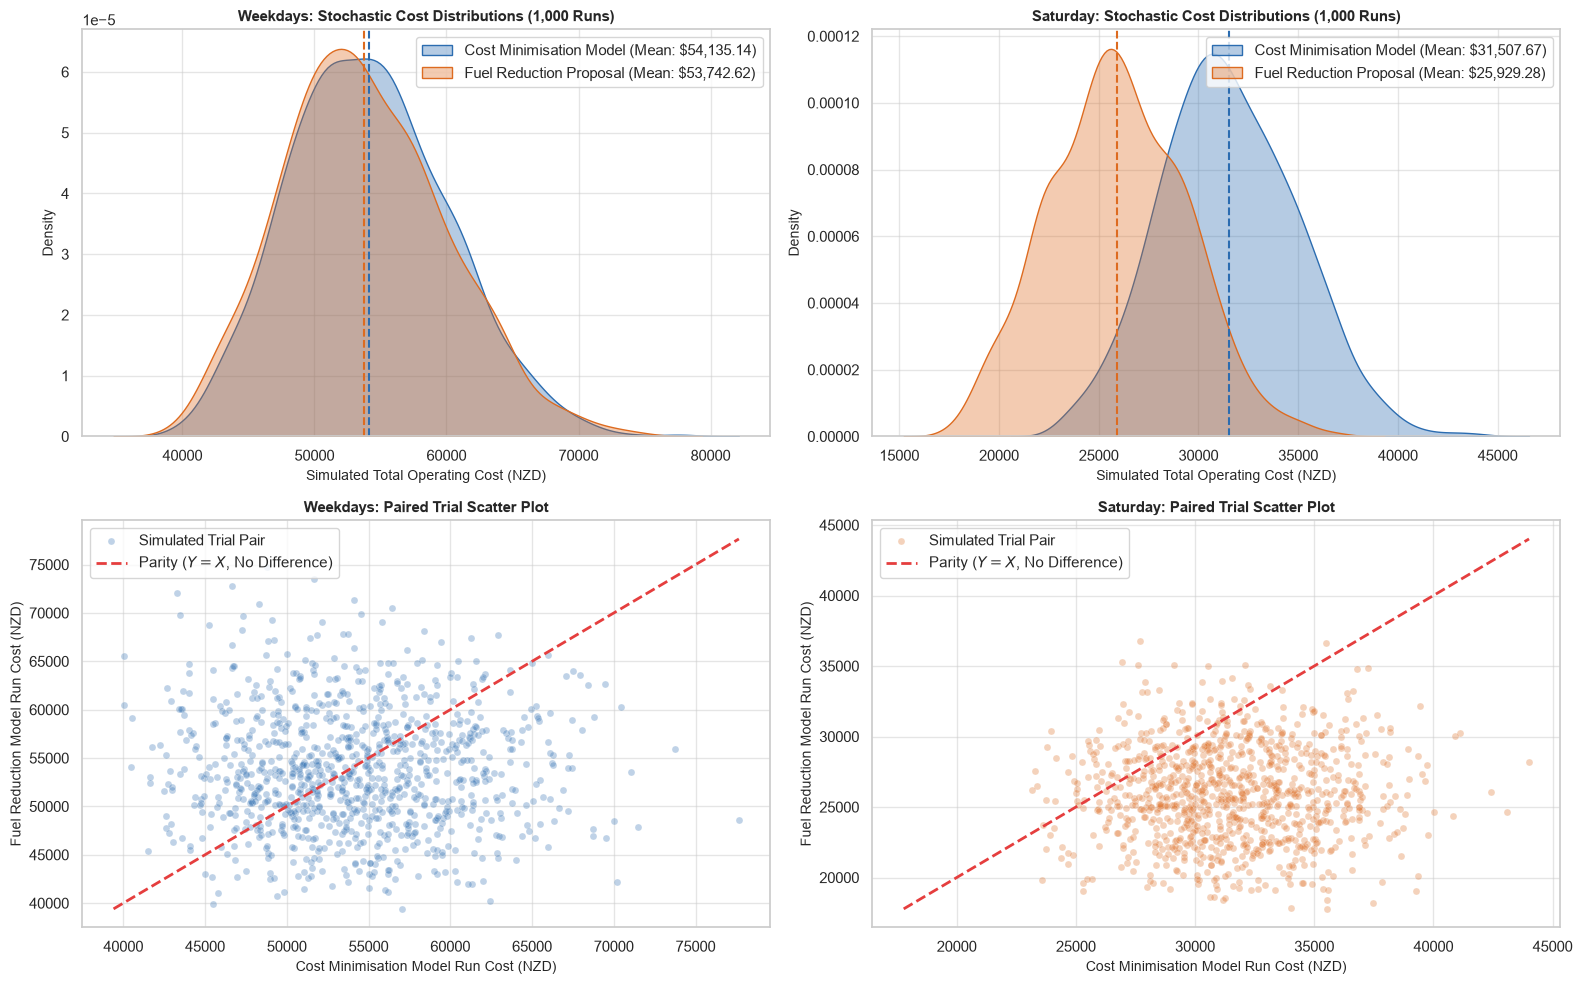

In [42]:
# ------------------------------------------------------------------------------
# 5. VISUALIZATION DASHBOARD
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top Left: Weekday Density
sns.kdeplot(wd_cost_min, label=f"Cost Minimisation Model (Mean: ${m_wd_min:,.2f})", color="#2B6CB0", fill=True, alpha=0.35, ax=axes[0, 0])
sns.kdeplot(wd_fuel_red, label=f"Fuel Reduction Proposal (Mean: ${m_wd_fuel:,.2f})", color="#DD6B20", fill=True, alpha=0.35, ax=axes[0, 0])
axes[0, 0].axvline(m_wd_min, color="#2B6CB0", linestyle="--", linewidth=1.5)
axes[0, 0].axvline(m_wd_fuel, color="#DD6B20", linestyle="--", linewidth=1.5)
axes[0, 0].set_title("Weekdays: Stochastic Cost Distributions (1,000 Runs)", fontsize=11, fontweight="bold")
axes[0, 0].set_xlabel("Simulated Total Operating Cost (NZD)", fontsize=10)
axes[0, 0].set_ylabel("Density", fontsize=10)
axes[0, 0].legend(loc="upper right", frameon=True, facecolor="white")

# Top Right: Saturday Density
sns.kdeplot(sat_cost_min, label=f"Cost Minimisation Model (Mean: ${m_sat_min:,.2f})", color="#2B6CB0", fill=True, alpha=0.35, ax=axes[0, 1])
sns.kdeplot(sat_fuel_red, label=f"Fuel Reduction Proposal (Mean: ${m_sat_fuel:,.2f})", color="#DD6B20", fill=True, alpha=0.35, ax=axes[0, 1])
axes[0, 1].axvline(m_sat_min, color="#2B6CB0", linestyle="--", linewidth=1.5)
axes[0, 1].axvline(m_sat_fuel, color="#DD6B20", linestyle="--", linewidth=1.5)
axes[0, 1].set_title("Saturday: Stochastic Cost Distributions (1,000 Runs)", fontsize=11, fontweight="bold")
axes[0, 1].set_xlabel("Simulated Total Operating Cost (NZD)", fontsize=10)
axes[0, 1].set_ylabel("Density", fontsize=10)
axes[0, 1].legend(loc="upper right", frameon=True, facecolor="white")

# Bottom Left: Weekdays Scatter Plot vs Parity Line
sns.scatterplot(x=wd_cost_min, y=wd_fuel_red, color="#2B6CB0", alpha=0.3, s=25, ax=axes[1, 0], label="Simulated Trial Pair")
min_wd, max_wd = min(min(wd_cost_min), min(wd_fuel_red)), max(max(wd_cost_min), max(wd_fuel_red))
axes[1, 0].plot([min_wd, max_wd], [min_wd, max_wd], color="#E53E3E", linestyle="--", linewidth=2, label="Parity ($Y=X$, No Difference)")
axes[1, 0].set_title("Weekdays: Paired Trial Scatter Plot", fontsize=11, fontweight="bold")
axes[1, 0].set_xlabel("Cost Minimisation Model Run Cost (NZD)", fontsize=10)
axes[1, 0].set_ylabel("Fuel Reduction Model Run Cost (NZD)", fontsize=10)
axes[1, 0].legend(loc="upper left", frameon=True, facecolor="white")

# Bottom Right: Saturday Scatter Plot vs Parity Line
sns.scatterplot(x=sat_cost_min, y=sat_fuel_red, color="#DD6B20", alpha=0.3, s=25, ax=axes[1, 1], label="Simulated Trial Pair")
min_sat, max_sat = min(min(sat_cost_min), min(sat_fuel_red)), max(max(sat_cost_min), max(sat_fuel_red))
axes[1, 1].plot([min_sat, max_sat], [min_sat, max_sat], color="#E53E3E", linestyle="--", linewidth=2, label="Parity ($Y=X$, No Difference)")
axes[1, 1].set_title("Saturday: Paired Trial Scatter Plot", fontsize=11, fontweight="bold")
axes[1, 1].set_xlabel("Cost Minimisation Model Run Cost (NZD)", fontsize=10)
axes[1, 1].set_ylabel("Fuel Reduction Model Run Cost (NZD)", fontsize=10)
axes[1, 1].legend(loc="upper left", frameon=True, facecolor="white")

plt.tight_layout()
plt.show()

Loaded 112 store-period demand observations.
Cost Minimisation: 60 routes loaded.
Fuel Reduction: 55 routes loaded.

ROUTE STRUCTURE CHECK
Cost Minimisation routes: 60
Fuel Reduction routes: 55
Identical complete route sets: False

Simulation complete.

SIMULATION DIFFERENCE CHECK
Weekday mean absolute difference: $1,144.32
Saturday mean absolute difference: $5,674.23
Weekday identical runs: 0/1000
Saturday identical runs: 0/1000

PAIRED T-TEST — COST MINIMISATION VS FUEL REDUCTION


,Schedule,Runs,Cost Minimisation Mean ($),Fuel Reduction Mean ($),Mean Difference ($),Std. Dev. Difference ($),t-statistic,p-value,Significant (5%)
0,Weekdays,1000,"$64,504.51","$64,517.02",$12.50,"$1,648.82",-0.240,0.8106,No
1,Saturday,1000,"$27,570.55","$21,896.32","$-5,674.23","$1,103.63",162.586,0.0000,Yes


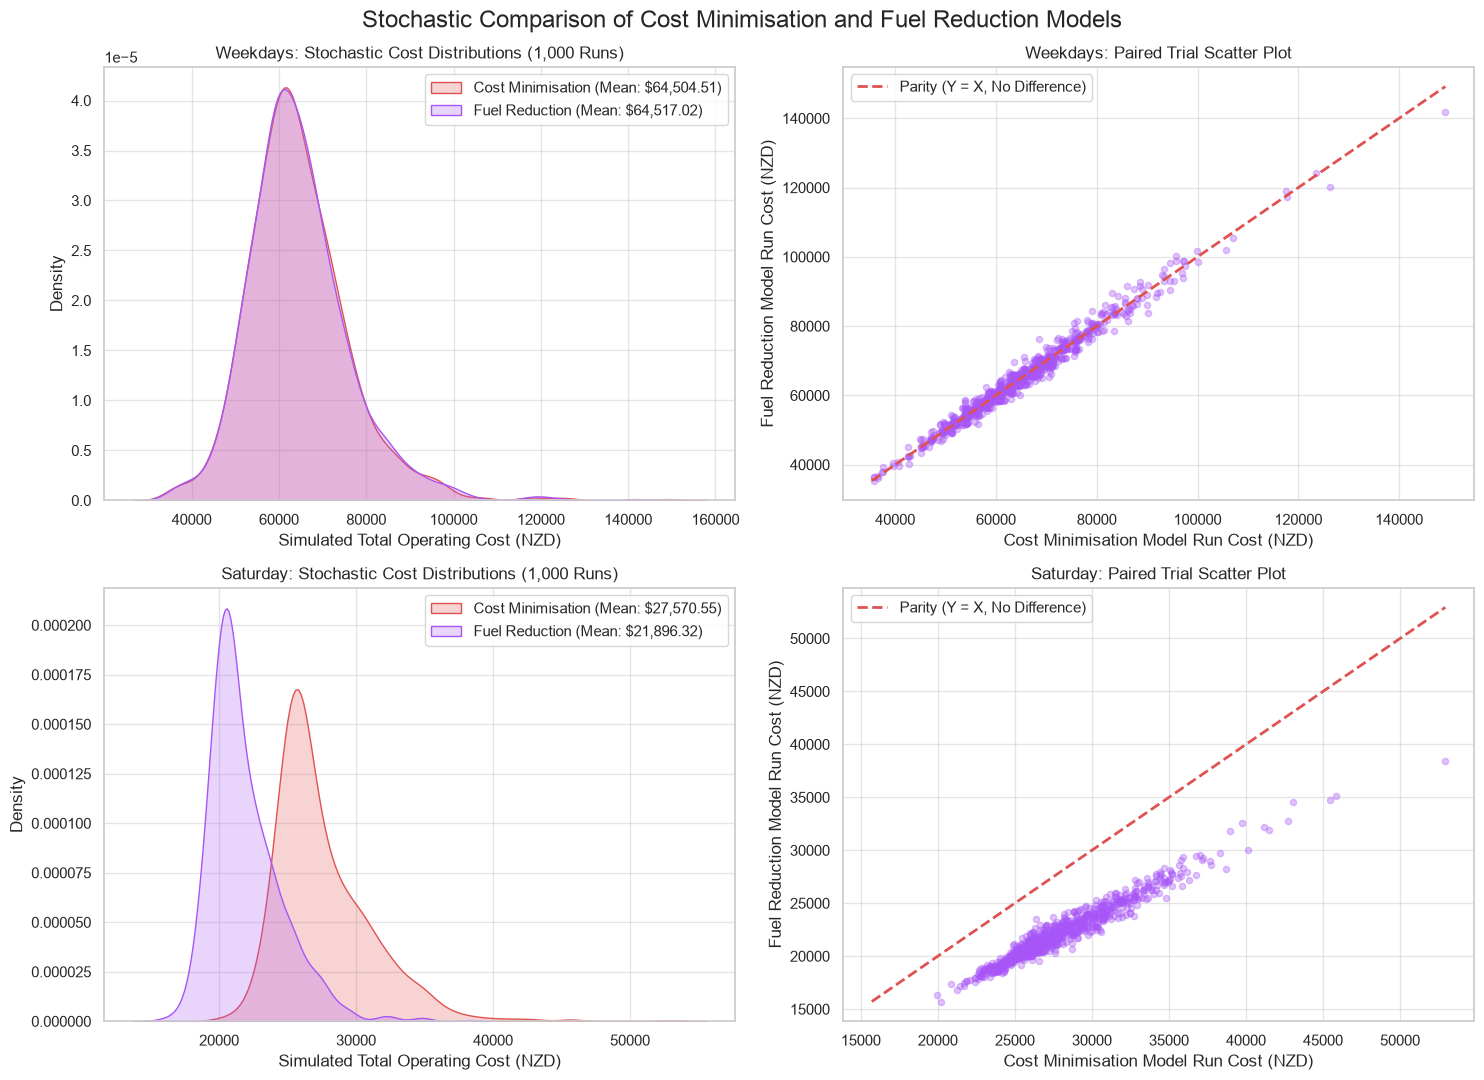

<Figure size 1200x600 with 0 Axes>


Results and report table saved.


In [50]:
# ============================================================
# STOCHASTIC PAIRED COMPARISON
# COST MINIMISATION VS FUEL REDUCTION
#
# Same demand + traffic shocks are applied to both models
# in each simulation, but each model is evaluated using
# its own deterministic optimal routes.
# ============================================================

from __future__ import annotations

import math
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================================
# 1. SETTINGS
# ============================================================

COST_ROUTE_FILE = Path(
    "project_data/Optimal_Routes_Cost.csv"
)

FUEL_ROUTE_FILE = Path(
    "project_data/Optimal_Routes_Fuel.csv"
)

DEMAND_FILE = Path(
    "project_data/demand_estimate.csv"
)

N_SIMULATIONS = 1000
RANDOM_SEED = 263

# ============================================================
# DEMAND VARIATION
# ============================================================

DAY_TO_DAY_DEMAND_SIGMA = 0.08
STORE_TO_STORE_DEMAND_SIGMA = 0.05

# ============================================================
# TRAFFIC VARIATION
# ============================================================

DAY_TO_DAY_TRAFFIC_SIGMA = 0.30
ROUTE_TO_ROUTE_TRAFFIC_SIGMA = 0.15

# ============================================================
# OPERATIONAL PARAMETERS
# ============================================================

TRUCK_CAPACITY = 16.0

PLANNED_SHIFT_HOURS = 3.5

UNLOAD_MINUTES_PER_PALLET = 18.0

TRUCK_COST_PER_HOUR = 220.0

OVERTIME_THRESHOLD_HOURS = 4.0
OVERTIME_COST_PER_BLOCK = 310.0

WET_LEASE_COST_PER_2H_BLOCK = 1400.0

# 20 trucks × 2 shifts × 3.5 hours
NORMAL_TRUCK_HOURS = (
        20 * 2 * 3.5
)


# ============================================================
# 2. HELPERS
# ============================================================

def parse_route(route_text: str) -> List[str]:
    return [
        part.strip()
        for part in str(route_text).split("->")
        if part.strip()
    ]


def ceil_hours_over_threshold(
        hours: float,
        threshold: float
) -> int:
    extra = hours - threshold

    if extra <= 0:
        return 0

    return int(
        math.ceil(extra - 1e-12)
    )


# ============================================================
# 3. LOAD DEMAND
# ============================================================

if not DEMAND_FILE.exists():
    raise FileNotFoundError(
        f"Missing demand file: "
        f"{DEMAND_FILE.resolve()}"
    )

demand_df = pd.read_csv(
    DEMAND_FILE
)

required_demand_columns = [
    "Supermarket",
    "Period",
    "Demand"
]

missing = [
    c for c in required_demand_columns
    if c not in demand_df.columns
]

if missing:
    raise ValueError(
        f"Missing demand columns: {missing}"
    )

demand_df["Demand"] = pd.to_numeric(
    demand_df["Demand"],
    errors="coerce"
)

if demand_df["Demand"].isna().any():
    raise ValueError(
        "Demand file contains invalid demand values."
    )

demand_lookup = {
    (
        row["Supermarket"],
        row["Period"]
    ): float(row["Demand"])

    for _, row in demand_df.iterrows()
}

print(
    f"Loaded {len(demand_df):,} "
    "store-period demand observations."
)


# ============================================================
# 4. LOAD ROUTE FILES
# ============================================================

def load_routes(
        filename: Path,
        model_name: str
):
    if not filename.exists():
        raise FileNotFoundError(
            f"Missing {filename.resolve()}"
        )

    df = pd.read_csv(filename)

    required = [
        "Day",
        "Route",
        "Duration_hours"
    ]

    missing = [
        c for c in required
        if c not in df.columns
    ]

    if missing:
        raise ValueError(
            f"{model_name}: missing columns "
            f"{missing}"
        )

    routes = []

    for _, row in df.iterrows():
        stops = parse_route(
            row["Route"]
        )

        stores = [
            stop
            for stop in stops
            if stop.lower() != "warehouse"
        ]

        routes.append(
            {
                "Day":
                    str(row["Day"]).strip(),

                "Route":
                    row["Route"],

                "Duration_hours":
                    float(row["Duration_hours"]),

                "Stores":
                    stores
            }
        )

    print(
        f"{model_name}: "
        f"{len(routes):,} routes loaded."
    )

    return routes


cost_routes = load_routes(
    COST_ROUTE_FILE,
    "Cost Minimisation"
)

fuel_routes = load_routes(
    FUEL_ROUTE_FILE,
    "Fuel Reduction"
)

# ============================================================
# 5. IMPORTANT CHECK
# ============================================================
#
# The models MUST NOT have identical route structures.
#
# If they do, identical results are expected.

cost_route_strings = {
    (
        r["Day"],
        r["Route"],
        r["Duration_hours"]
    )
    for r in cost_routes
}

fuel_route_strings = {
    (
        r["Day"],
        r["Route"],
        r["Duration_hours"]
    )
    for r in fuel_routes
}

print("\n" + "=" * 70)
print("ROUTE STRUCTURE CHECK")
print("=" * 70)

print(
    f"Cost Minimisation routes: "
    f"{len(cost_routes)}"
)

print(
    f"Fuel Reduction routes: "
    f"{len(fuel_routes)}"
)

print(
    f"Identical complete route sets: "
    f"{cost_route_strings == fuel_route_strings}"
)

if cost_route_strings == fuel_route_strings:
    print(
        "\nWARNING:"
        "\nThe two route files contain identical "
        "routes and durations."
        "\nThe stochastic costs may therefore be identical."
    )


# ============================================================
# 6. PREPARE ONE MODEL FOR SIMULATION
# ============================================================

def prepare_routes(routes):
    prepared = []

    for route in routes:
        stores = route["Stores"]

        # Demand is generated dynamically during
        # every simulation.

        prepared.append(
            {
                "Day":
                    route["Day"],

                "Route":
                    route["Route"],

                "Duration_hours":
                    route["Duration_hours"],

                "Stores":
                    stores
            }
        )

    return prepared


cost_routes = prepare_routes(
    cost_routes
)

fuel_routes = prepare_routes(
    fuel_routes
)


# ============================================================
# 7. SIMULATE ONE MODEL
# ============================================================

def simulate_schedule(
        routes,
        weekday_demand_factors,
        saturday_demand_factor,
        weekday_traffic_factor,
        saturday_traffic_factor,
        demand_store_factors,
        traffic_route_factors
):
    weekday_cost = 0.0
    saturday_cost = 0.0

    weekday_demand = 0.0
    saturday_demand = 0.0

    weekday_hours = 0.0
    saturday_hours = 0.0

    weekday_overtime = 0
    saturday_overtime = 0

    weekday_wet_blocks = 0
    saturday_wet_blocks = 0

    # --------------------------------------------------------
    # Each model uses ITS OWN route list.
    # --------------------------------------------------------

    for route_index, route in enumerate(routes):

        day = route["Day"]

        stores = route["Stores"]

        original_duration = (
            route["Duration_hours"]
        )

        if day == "Weekdays":

            period = "Weekdays"

            demand_day_factor = (
                weekday_demand_factors
            )

            traffic_day_factor = (
                weekday_traffic_factor
            )

        elif day == "Saturday":

            period = "Saturday"

            demand_day_factor = (
                saturday_demand_factor
            )

            traffic_day_factor = (
                saturday_traffic_factor
            )

        else:

            raise ValueError(
                f"Unexpected day type: {day}"
            )

        # ====================================================
        # ROUTE DEMAND
        # ====================================================

        route_demand = 0.0

        for store in stores:

            key = (
                store,
                period
            )

            if key not in demand_lookup:
                raise ValueError(
                    f"No demand estimate found for "
                    f"{store} ({period})"
                )

            baseline = demand_lookup[key]

            store_factor = (
                demand_store_factors[
                    (route_index, store, period)
                ]
            )

            simulated = (
                    baseline
                    * demand_day_factor
                    * store_factor
            )

            # Preserve the original simulation approach
            simulated = np.ceil(simulated)

            route_demand += simulated

        # ====================================================
        # UNLOADING
        # ====================================================

        unload_hours = (
                route_demand
                * UNLOAD_MINUTES_PER_PALLET
                / 60.0
        )

        # ====================================================
        # DRIVING
        # ====================================================

        base_drive_hours = max(
            0.0,
            original_duration
            - unload_hours
        )

        # ====================================================
        # TRAFFIC
        # ====================================================

        route_traffic_factor = (
            traffic_route_factors[
                route_index
            ]
        )

        traffic_multiplier = (
                traffic_day_factor
                * route_traffic_factor
        )

        actual_hours = (
                base_drive_hours
                * traffic_multiplier
                + unload_hours
        )

        # ====================================================
        # BASE COST
        # ====================================================

        normal_cost = (
                actual_hours
                * TRUCK_COST_PER_HOUR
        )

        # ====================================================
        # OVERTIME
        # ====================================================

        overtime_blocks = (
            ceil_hours_over_threshold(
                actual_hours,
                OVERTIME_THRESHOLD_HOURS
            )
        )

        overtime_cost = (
                overtime_blocks
                * OVERTIME_COST_PER_BLOCK
        )

        # ====================================================
        # ADD TO CORRECT DAY
        # ====================================================

        if period == "Weekdays":

            weekday_demand += route_demand

            weekday_hours += actual_hours

            weekday_overtime += (
                overtime_blocks
            )

            weekday_cost += (
                    normal_cost
                    + overtime_cost
            )

        else:

            saturday_demand += route_demand

            saturday_hours += actual_hours

            saturday_overtime += (
                overtime_blocks
            )

            saturday_cost += (
                    normal_cost
                    + overtime_cost
            )

    # ========================================================
    # WET LEASING
    # ========================================================

    weekday_extra_hours = max(
        0.0,
        weekday_hours
        - NORMAL_TRUCK_HOURS
    )

    weekday_wet_blocks = (
        math.ceil(
            weekday_extra_hours / 2.0
            - 1e-12
        )
        if weekday_extra_hours > 0
        else 0
    )

    weekday_wet_cost = (
            weekday_wet_blocks
            * WET_LEASE_COST_PER_2H_BLOCK
    )

    weekday_cost += weekday_wet_cost

    saturday_extra_hours = max(
        0.0,
        saturday_hours
        - NORMAL_TRUCK_HOURS
    )

    saturday_wet_blocks = (
        math.ceil(
            saturday_extra_hours / 2.0
            - 1e-12
        )
        if saturday_extra_hours > 0
        else 0
    )

    saturday_wet_cost = (
            saturday_wet_blocks
            * WET_LEASE_COST_PER_2H_BLOCK
    )

    saturday_cost += saturday_wet_cost

    return {

        "Weekday_Cost":
            weekday_cost,

        "Saturday_Cost":
            saturday_cost,

        "Weekday_Demand":
            weekday_demand,

        "Saturday_Demand":
            saturday_demand,

        "Weekday_Hours":
            weekday_hours,

        "Saturday_Hours":
            saturday_hours,

        "Weekday_Overtime":
            weekday_overtime,

        "Saturday_Overtime":
            saturday_overtime,

        "Weekday_Wet_Lease":
            weekday_wet_blocks,

        "Saturday_Wet_Lease":
            saturday_wet_blocks
    }


# ============================================================
# 8. PAIRED SIMULATION
# ============================================================
#
# CRITICAL:
#
# For every simulation:
#
#       SAME RANDOM SHOCKS
#              ↓
#       ┌───────────────┐
#       │               │
#   COST ROUTES     FUEL ROUTES
#       │               │
#       └───────┬───────┘
#               ↓
#          COST DIFFERENCE
#
# This is what makes it a paired experiment.

rng = np.random.default_rng(
    RANDOM_SEED
)

cost_results = []
fuel_results = []

for simulation in range(
        1,
        N_SIMULATIONS + 1
):

    # ========================================================
    # COMMON DAILY DEMAND SHOCKS
    # ========================================================

    weekday_demand_factor = rng.lognormal(
        mean=(
                -0.5
                * DAY_TO_DAY_DEMAND_SIGMA ** 2
        ),
        sigma=DAY_TO_DAY_DEMAND_SIGMA
    )

    saturday_demand_factor = rng.lognormal(
        mean=(
                -0.5
                * DAY_TO_DAY_DEMAND_SIGMA ** 2
        ),
        sigma=DAY_TO_DAY_DEMAND_SIGMA
    )

    # ========================================================
    # COMMON DAILY TRAFFIC SHOCKS
    # ========================================================

    weekday_traffic_factor = rng.lognormal(
        mean=(
                -0.5
                * DAY_TO_DAY_TRAFFIC_SIGMA ** 2
        ),
        sigma=DAY_TO_DAY_TRAFFIC_SIGMA
    )

    saturday_traffic_factor = rng.lognormal(
        mean=(
                -0.5
                * DAY_TO_DAY_TRAFFIC_SIGMA ** 2
        ),
        sigma=DAY_TO_DAY_TRAFFIC_SIGMA
    )

    # ========================================================
    # COMMON STORE DEMAND SHOCKS
    # ========================================================
    #
    # Generate shocks by STORE rather than by route.
    #
    # This is important because the same store should receive
    # the same simulated demand regardless of which model's
    # route visits it.

    demand_store_factors = {}

    stores_in_demand = (
        demand_df[
            ["Supermarket", "Period"]
        ]
        .drop_duplicates()
        .itertuples(index=False)
    )

    store_factor_lookup = {}

    for row in stores_in_demand:
        factor = rng.lognormal(
            mean=(
                    -0.5
                    * STORE_TO_STORE_DEMAND_SIGMA ** 2
            ),
            sigma=STORE_TO_STORE_DEMAND_SIGMA
        )

        store_factor_lookup[
            (row.Supermarket, row.Period)
        ] = factor

    # Both models use the same store shocks.
    #
    # Convert into the dictionary expected by the
    # simulation function.

    for route_index, route in enumerate(cost_routes):

        period = route["Day"]

        for store in route["Stores"]:
            demand_store_factors[
                (route_index, store, period)
            ] = store_factor_lookup[
                (store, period)
            ]

    # --------------------------------------------------------
    # Fuel model has its own route indexing
    # but the SAME underlying store shocks.
    # --------------------------------------------------------

    fuel_demand_store_factors = {}

    for route_index, route in enumerate(fuel_routes):

        period = route["Day"]

        for store in route["Stores"]:
            fuel_demand_store_factors[
                (route_index, store, period)
            ] = store_factor_lookup[
                (store, period)
            ]

    # ========================================================
    # COMMON ROUTE TRAFFIC SHOCKS
    # ========================================================
    #
    # Traffic is route-specific, so each route gets a
    # stochastic traffic multiplier.
    #
    # The shocks are generated independently for the two
    # schedules because their routes are different.

    cost_traffic_route_factors = {}

    for route_index in range(
            len(cost_routes)
    ):
        cost_traffic_route_factors[
            route_index
        ] = rng.lognormal(
            mean=(
                    -0.5
                    * ROUTE_TO_ROUTE_TRAFFIC_SIGMA ** 2
            ),
            sigma=ROUTE_TO_ROUTE_TRAFFIC_SIGMA
        )

    fuel_traffic_route_factors = {}

    for route_index in range(
            len(fuel_routes)
    ):
        fuel_traffic_route_factors[
            route_index
        ] = rng.lognormal(
            mean=(
                    -0.5
                    * ROUTE_TO_ROUTE_TRAFFIC_SIGMA ** 2
            ),
            sigma=ROUTE_TO_ROUTE_TRAFFIC_SIGMA
        )

    # ========================================================
    # SIMULATE COST MODEL
    # ========================================================

    cost_sim = simulate_schedule(

        routes=cost_routes,

        weekday_demand_factors=
        weekday_demand_factor,

        saturday_demand_factor=
        saturday_demand_factor,

        weekday_traffic_factor=
        weekday_traffic_factor,

        saturday_traffic_factor=
        saturday_traffic_factor,

        demand_store_factors=
        demand_store_factors,

        traffic_route_factors=
        cost_traffic_route_factors
    )

    # ========================================================
    # SIMULATE FUEL MODEL
    # ========================================================

    fuel_sim = simulate_schedule(

        routes=fuel_routes,

        weekday_demand_factors=
        weekday_demand_factor,

        saturday_demand_factor=
        saturday_demand_factor,

        weekday_traffic_factor=
        weekday_traffic_factor,

        saturday_traffic_factor=
        saturday_traffic_factor,

        demand_store_factors=
        fuel_demand_store_factors,

        traffic_route_factors=
        fuel_traffic_route_factors
    )

    # ========================================================
    # SAVE
    # ========================================================

    cost_results.append(
        {
            "Simulation": simulation,
            **cost_sim
        }
    )

    fuel_results.append(
        {
            "Simulation": simulation,
            **fuel_sim
        }
    )

cost_results = pd.DataFrame(
    cost_results
)

fuel_results = pd.DataFrame(
    fuel_results
)

print(
    "\nSimulation complete."
)

# ============================================================
# 9. CHECK THAT RESULTS ARE ACTUALLY DIFFERENT
# ============================================================

print("\n" + "=" * 70)
print("SIMULATION DIFFERENCE CHECK")
print("=" * 70)

weekday_difference = (
        cost_results["Weekday_Cost"]
        - fuel_results["Weekday_Cost"]
)

saturday_difference = (
        cost_results["Saturday_Cost"]
        - fuel_results["Saturday_Cost"]
)

print(
    f"Weekday mean absolute difference: "
    f"${weekday_difference.abs().mean():,.2f}"
)

print(
    f"Saturday mean absolute difference: "
    f"${saturday_difference.abs().mean():,.2f}"
)

print(
    f"Weekday identical runs: "
    f"{(weekday_difference == 0).sum():,}"
    f"/{N_SIMULATIONS}"
)

print(
    f"Saturday identical runs: "
    f"{(saturday_difference == 0).sum():,}"
    f"/{N_SIMULATIONS}"
)

# ============================================================
# 10. PAIRED T-TEST
# ============================================================

weekday_ttest = stats.ttest_rel(
    cost_results["Weekday_Cost"],
    fuel_results["Weekday_Cost"]
)

saturday_ttest = stats.ttest_rel(
    cost_results["Saturday_Cost"],
    fuel_results["Saturday_Cost"]
)


def paired_statistics(
        cost_series,
        fuel_series,
        ttest
):
    difference = (
            fuel_series
            - cost_series
    )

    return {

        "Cost Mean":
            cost_series.mean(),

        "Fuel Mean":
            fuel_series.mean(),

        "Mean Difference":
            difference.mean(),

        "Std Difference":
            difference.std(
                ddof=1
            ),

        "t-statistic":
            ttest.statistic,

        "p-value":
            ttest.pvalue,

        "Significant":
            "Yes"
            if ttest.pvalue < 0.05
            else "No"
    }


weekday_stats = paired_statistics(
    cost_results["Weekday_Cost"],
    fuel_results["Weekday_Cost"],
    weekday_ttest
)

saturday_stats = paired_statistics(
    cost_results["Saturday_Cost"],
    fuel_results["Saturday_Cost"],
    saturday_ttest
)

# ============================================================
# 11. REPORT TABLE
# ============================================================

report_table = pd.DataFrame(
    [
        {
            "Schedule":
                "Weekdays",

            "Runs":
                N_SIMULATIONS,

            "Cost Minimisation Mean ($)":
                weekday_stats["Cost Mean"],

            "Fuel Reduction Mean ($)":
                weekday_stats["Fuel Mean"],

            "Mean Difference ($)":
                weekday_stats["Mean Difference"],

            "Std. Dev. Difference ($)":
                weekday_stats["Std Difference"],

            "t-statistic":
                weekday_stats["t-statistic"],

            "p-value":
                weekday_stats["p-value"],

            "Significant (5%)":
                weekday_stats["Significant"]
        },

        {
            "Schedule":
                "Saturday",

            "Runs":
                N_SIMULATIONS,

            "Cost Minimisation Mean ($)":
                saturday_stats["Cost Mean"],

            "Fuel Reduction Mean ($)":
                saturday_stats["Fuel Mean"],

            "Mean Difference ($)":
                saturday_stats["Mean Difference"],

            "Std. Dev. Difference ($)":
                saturday_stats["Std Difference"],

            "t-statistic":
                saturday_stats["t-statistic"],

            "p-value":
                saturday_stats["p-value"],

            "Significant (5%)":
                saturday_stats["Significant"]
        }
    ]
)

print("\n" + "=" * 110)
print("PAIRED T-TEST — COST MINIMISATION VS FUEL REDUCTION")
print("=" * 110)

display(
    report_table.style.format(
        {
            "Cost Minimisation Mean ($)":
                "${:,.2f}",

            "Fuel Reduction Mean ($)":
                "${:,.2f}",

            "Mean Difference ($)":
                "${:,.2f}",

            "Std. Dev. Difference ($)":
                "${:,.2f}",

            "t-statistic":
                "{:.3f}",

            "p-value":
                "{:.4f}"
        }
    )
)

## ============================================================
# 12. COMBINED PLOTS
# ============================================================

# Same palette used in the other simulation plots
COST_COLOUR = "#E05252"
FUEL_COLOUR = "#A855F7"


fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 11)
)

# ============================================================
# TOP LEFT — WEEKDAY DISTRIBUTIONS
# ============================================================

sns.kdeplot(
    cost_results["Weekday_Cost"],
    fill=True,
    alpha=0.25,
    color=COST_COLOUR,
    label=(
        f"Cost Minimisation "
        f"(Mean: ${cost_results['Weekday_Cost'].mean():,.2f})"
    ),
    ax=axes[0, 0]
)

sns.kdeplot(
    fuel_results["Weekday_Cost"],
    fill=True,
    alpha=0.25,
    color=FUEL_COLOUR,
    label=(
        f"Fuel Reduction "
        f"(Mean: ${fuel_results['Weekday_Cost'].mean():,.2f})"
    ),
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Weekdays: Stochastic Cost Distributions (1,000 Runs)"
)

axes[0, 0].set_xlabel(
    "Simulated Total Operating Cost (NZD)"
)

axes[0, 0].set_ylabel(
    "Density"
)

axes[0, 0].legend()


# ============================================================
# TOP RIGHT — WEEKDAY PAIRED SCATTER
# ============================================================

axes[0, 1].scatter(
    cost_results["Weekday_Cost"],
    fuel_results["Weekday_Cost"],
    alpha=0.35,
    s=20,
    color=FUEL_COLOUR
)

min_val = min(
    cost_results["Weekday_Cost"].min(),
    fuel_results["Weekday_Cost"].min()
)

max_val = max(
    cost_results["Weekday_Cost"].max(),
    fuel_results["Weekday_Cost"].max()
)

axes[0, 1].plot(
    [min_val, max_val],
    [min_val, max_val],
    color=COST_COLOUR,
    linestyle="--",
    linewidth=2,
    label="Parity (Y = X, No Difference)"
)

axes[0, 1].set_title(
    "Weekdays: Paired Trial Scatter Plot"
)

axes[0, 1].set_xlabel(
    "Cost Minimisation Model Run Cost (NZD)"
)

axes[0, 1].set_ylabel(
    "Fuel Reduction Model Run Cost (NZD)"
)

axes[0, 1].legend()


# ============================================================
# BOTTOM LEFT — SATURDAY DISTRIBUTIONS
# ============================================================

sns.kdeplot(
    cost_results["Saturday_Cost"],
    fill=True,
    alpha=0.25,
    color=COST_COLOUR,
    label=(
        f"Cost Minimisation "
        f"(Mean: ${cost_results['Saturday_Cost'].mean():,.2f})"
    ),
    ax=axes[1, 0]
)

sns.kdeplot(
    fuel_results["Saturday_Cost"],
    fill=True,
    alpha=0.25,
    color=FUEL_COLOUR,
    label=(
        f"Fuel Reduction "
        f"(Mean: ${fuel_results['Saturday_Cost'].mean():,.2f})"
    ),
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Saturday: Stochastic Cost Distributions (1,000 Runs)"
)

axes[1, 0].set_xlabel(
    "Simulated Total Operating Cost (NZD)"
)

axes[1, 0].set_ylabel(
    "Density"
)

axes[1, 0].legend()


# ============================================================
# BOTTOM RIGHT — SATURDAY PAIRED SCATTER
# ============================================================

axes[1, 1].scatter(
    cost_results["Saturday_Cost"],
    fuel_results["Saturday_Cost"],
    alpha=0.35,
    s=20,
    color=FUEL_COLOUR
)

min_val = min(
    cost_results["Saturday_Cost"].min(),
    fuel_results["Saturday_Cost"].min()
)

max_val = max(
    cost_results["Saturday_Cost"].max(),
    fuel_results["Saturday_Cost"].max()
)

axes[1, 1].plot(
    [min_val, max_val],
    [min_val, max_val],
    color=COST_COLOUR,
    linestyle="--",
    linewidth=2,
    label="Parity (Y = X, No Difference)"
)

axes[1, 1].set_title(
    "Saturday: Paired Trial Scatter Plot"
)

axes[1, 1].set_xlabel(
    "Cost Minimisation Model Run Cost (NZD)"
)

axes[1, 1].set_ylabel(
    "Fuel Reduction Model Run Cost (NZD)"
)

axes[1, 1].legend()


# ============================================================
# OVERALL TITLE
# ============================================================

fig.suptitle(
    "Stochastic Comparison of Cost Minimisation and Fuel Reduction Models",
    fontsize=17
)

plt.tight_layout()
plt.show()

axes[1, 1].set_xlabel(
    "Cost Minimisation Model Run Cost (NZD)"
)

axes[1, 1].set_ylabel(
    "Fuel Reduction Model Run Cost (NZD)"
)

axes[1, 1].legend()

fig.suptitle(
    "Stochastic Comparison of Cost Minimisation and Fuel Reduction Models",
    fontsize=17
)

plt.tight_layout()
plt.show()

# ============================================================
# 13. SAVE REPORT TABLE
# ============================================================

report_table.to_csv(
    "paired_ttest_cost_vs_fuel.csv",
    index=False
)

cost_results.to_csv(
    "cost_minimisation_stochastic_results.csv",
    index=False
)

fuel_results.to_csv(
    "fuel_reduction_stochastic_results.csv",
    index=False
)

print(
    "\nResults and report table saved."
)
